In [1]:
from utils.utils import DataLoader, DopplerDataset
from utils.utils import plot_learning_curves, plot_multiple_learning_curves, compare_multiple_learning_curves
from utils.utils import generate_prediction_video
from utils.utils import plot_predictions_vs_groundtruth
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import cv2
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [ ]:
l_exp = [f"Regression/BackToResNet4"]
folds = list(range(3, 4))

for exp in l_exp :
    for fold in folds :
        print(f"🔔 Starting {exp} fold {fold}")
        stream = open(f"exp_list/{exp}.yaml", 'r')
        param  = yaml.safe_load(stream)
        param["TRAINING"]["DEVICE"] = 'mps'
        param["DATASET"]["FOLD_NUMBER"] = fold

        to_load = ["max_values", "labels", "magnitudes", "video_frames"]

        data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
        
        resultsPath = os.path.join("results", exp, f"fold{fold}")

        # Create the directory
        if not os.path.exists(resultsPath):
            os.makedirs(resultsPath)

        #frame = data_loader.get_video_frame("NewExp29", 500)

        # Load number of people - NewExp29_frames.npy
        #gts = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_gts.npy"), allow_pickle=True)
        #preds = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_preds.npy"), allow_pickle=True)
        #frames_number = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_frames.npy"), allow_pickle=True)

        exp_ns = [1, 14, 20, 30, 40]
        
        for exp_n in exp_ns:
            exp_name = f"NewExp{exp_n}"

            generate_prediction_video(
                exp_name=exp_name,
                data_loader=data_loader,
                results_path=resultsPath,
                save_path=f"visualizations/fold{fold}_exp{exp_n}_visu.mp4",
                output_fps=24
            )

        #myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

        # Print number of parameters of myNetwork.model
        #num_params = sum(p.numel() for p in myNetwork.model.parameters())
        #print(f"Number of parameters: {num_params}")

        #myNetwork.visualize_data_augmentation()

        # Train the network
        #train_losses, val_losses =  myNetwork.train()

        # Test the network
        #myNetwork.loadWeight()
        #myNetwork.test(fold)


🔔 Starting Regression/BackToResNet4 fold 3
Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:02<00:00, 18.01exp/s]


✅ Vidéo exportée : visualizations/fold3_exp1_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp14_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp20_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp30_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp40_visu.mp4


In [ ]:
exp = "Regression/BackToResNet4"
fold = 6
stream = open(f"exp_list/{exp}.yaml", 'r')
param  = yaml.safe_load(stream)
param["TRAINING"]["DEVICE"] = 'mps'
param["DATASET"]["FOLD_NUMBER"] = fold

to_load = ["max_values", "labels", "magnitudes", "video_frames"]
data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
resultsPath = os.path.join("results", exp, f"fold{fold}")

exp_ns = [35]

results_by_experiment = {}

for exp_n in exp_ns:
    # Read the gts, preds and frames_number from resultsPath
    exp_name = f"NewExp{exp_n}"
    frame = data_loader.get_video_frame(exp_name, 125)
    # Load number of people - NewExp29_frames.npy
    gts = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_gts.npy"), allow_pickle=True)
    preds = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_preds.npy"), allow_pickle=True)
    frames_number = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_frames.npy"), allow_pickle=True)

    results_by_experiment[exp_name] = {
        "gts": gts,
        "preds": preds,
        "frames": frames_number
    }

save_path = os.path.join(resultsPath, "_ExtraPlots")

# Make the font size bigger
plt.rcParams.update({'font.size': 16})

plot_predictions_vs_groundtruth(results_by_experiment, save_path)


Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:00<00:00, 52.88exp/s]


[NewExp47] MAE - Raw: 1.11
[NewExp47] MAE - Aggregated: 1.06
[NewExp47] MAE - Rounded: 0.98
[NewExp47] MAE - Raw GT vs Aggregated Pred: 1.05
[NewExp47] MAE - Aggregated GT vs Aggregated Pred: 1.06


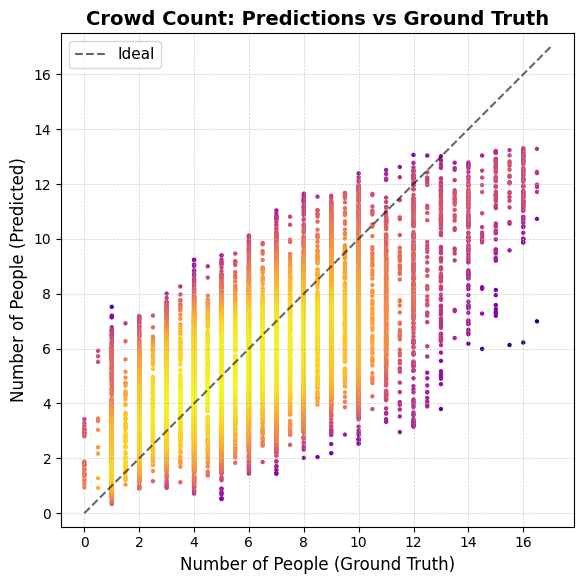

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import LogNorm

# Paramètres
base_path = "/Users/hippolytehilgers/Desktop/UCL_Hip/Mémoire/Code/DeepLearning/results"
exp_name = "Regression/AFinalExp16"
fold = range(1, 9)
exps_n = range(61, 81)

# Initialisation des listes pour stocker toutes les valeurs
all_preds = []
all_gts = []

# Chargement des données pour chaque expérience
for n in exps_n:
    folder = f"{base_path}/{exp_name}/fold{fold}/fold{fold}/_PerExperimentPlots"
    preds_path = os.path.join(folder, f"NewExp{n}_preds.npy")
    gts_path = os.path.join(folder, f"NewExp{n}_gts.npy")

    preds = np.load(preds_path)
    gts = np.load(gts_path)

    all_preds.append(preds)
    all_gts.append(gts)

# Concaténation de toutes les expériences
all_preds = np.concatenate(all_preds)
all_gts = np.concatenate(all_gts)

# Filtrage des points dans la zone [0, 17]
mask = (all_gts >= 0) & (all_preds >= 0) & (all_gts <= 17) & (all_preds <= 17)
all_gts = all_gts[mask]
all_preds = all_preds[mask]

# Calcul de la densité
xy = np.vstack([all_gts, all_preds])
z = gaussian_kde(xy)(xy)

# Tri pour rendre visibles les points denses
idx = z.argsort()
x, y, z = all_gts[idx], all_preds[idx], z[idx]

# Style du plot
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Plot
plt.figure(figsize=(6, 6))
sc = plt.scatter(x, y, c=z, cmap='plasma', norm=LogNorm(), s=10, edgecolors='none')

# Diagonale parfaite
plt.plot([0, 17], [0, 17], color='black', linestyle='--', alpha = 0.6, linewidth=1.5, label='Ideal')

# Axes
ax = plt.gca()
ax.set_xticks(np.arange(0, 17, 2))
ax.set_yticks(np.arange(0, 17, 2))
ax.set_xlim(0, 17)
ax.set_ylim(0, 17)

# Labels, titre, légende
plt.xlabel('Number of People (Ground Truth)', fontsize=12)
plt.ylabel('Number of People (Predicted)', fontsize=12)
plt.title('Crowd Count: Predictions vs Ground Truth', fontsize=14, weight='bold')

#plt.colorbar(sc, label='Log-scaled Point Density')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.axis('equal')
plt.tight_layout()

# Sauvegarde
plt.savefig("pred_vs_gt_scatter_log_density.pdf", dpi=300)
#plt.show()


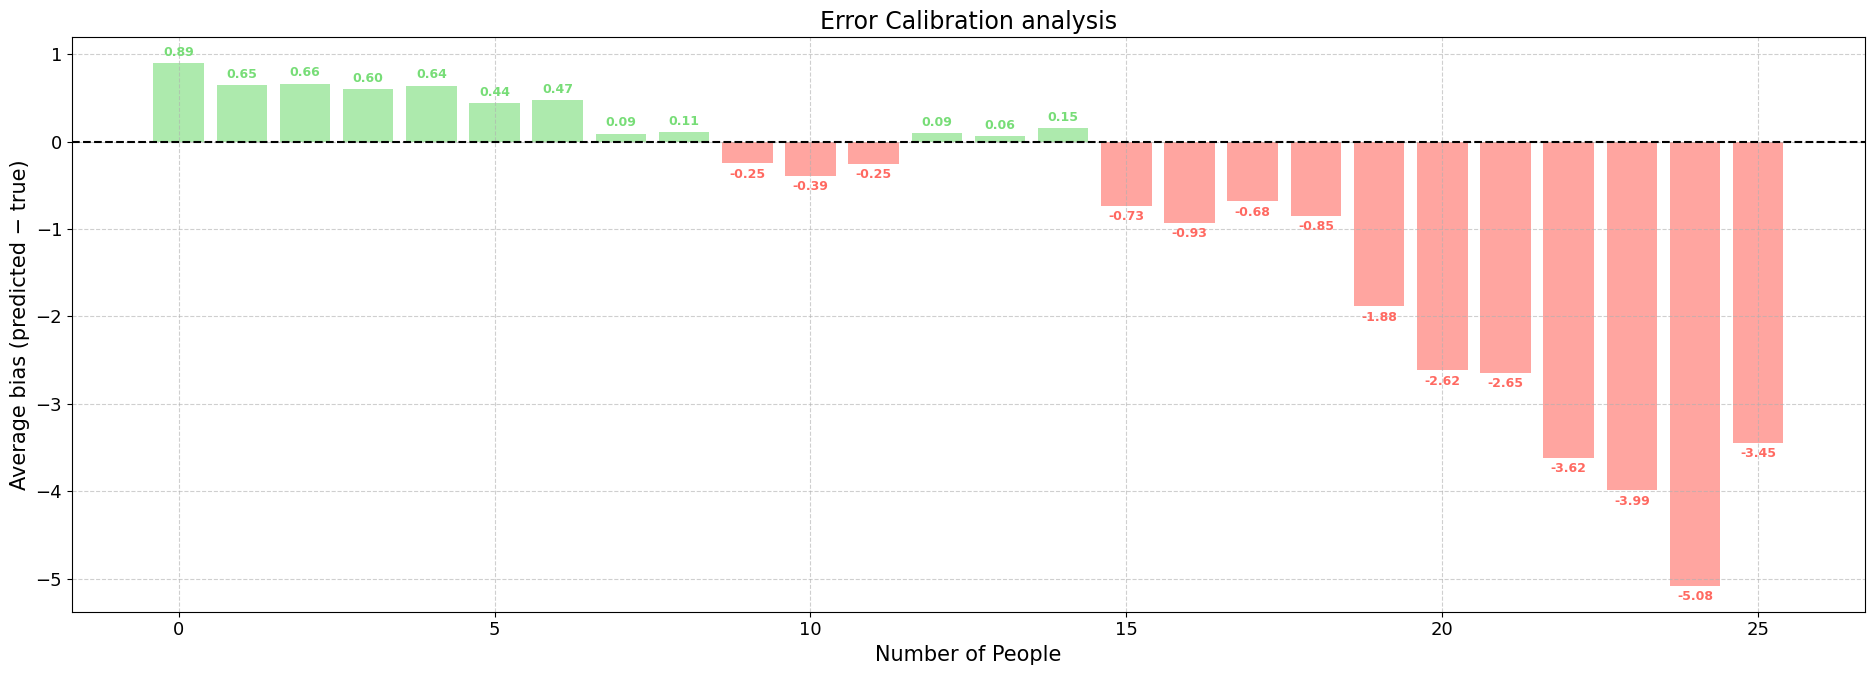

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Base path
base_path = "/Users/hippolytehilgers/Desktop/UCL_Hip/Mémoire/Code/DeepLearning/results"
exp_path = "Regression/AFinalExp16"
folds = range(1, 9)

all_preds = []
all_gts = []

# Parcours automatique des fichiers *_preds.npy et *_gts.npy dans chaque fold
for fold in folds:
    pattern = os.path.join(base_path, exp_path, f"fold{fold}", f"fold{fold}", "_PerExperimentPlots", "NewExp*_preds.npy")
    pred_files = sorted(glob(pattern))
    
    for pred_path in pred_files:
        gts_path = pred_path.replace("_preds.npy", "_gts.npy")
        if os.path.exists(gts_path):
            preds = np.load(pred_path)
            gts = np.load(gts_path)
            all_preds.append(preds)
            all_gts.append(gts)

# Concaténation
all_preds = np.concatenate(all_preds)
all_gts = np.concatenate(all_gts)

# Arrondi des labels pour regroupement
labels_rounded = np.round(all_gts).astype(int)

# Calcul du biais par label
unique_labels = np.unique(labels_rounded)
bias_by_label = []
for label in unique_labels:
    mask = labels_rounded == label
    bias = np.mean(all_preds[mask] - all_gts[mask])
    bias_by_label.append(bias)

#Make font size bigger
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13
})
# Création du graphique avec couleurs pastel et texte en gras + couleur
plt.figure(figsize=(19, 7))
for x, bias in zip(unique_labels, bias_by_label):
    color = '#77dd77' if bias > 0 else '#ff6961'  # vert pastel / rouge pastel
    plt.bar(x, bias, color=color, alpha=0.6)
    va = 'bottom' if bias > 0 else 'top'
    offset = 0.05 if bias > 0 else -0.05
    plt.text(x, bias + offset, f"{bias:.2f}", ha='center', va=va, fontsize=9,
             fontweight='bold', color=color)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Number of People")
plt.ylabel("Average bias (predicted − true)")
plt.title("Error Calibration analysis")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("global_calibration_analysis.pdf")
#plt.show()



In [5]:
import cv2

exp = "Regression/BackToResNet4"
fold = 4
stream = open(f"exp_list/{exp}.yaml", 'r')
param  = yaml.safe_load(stream)
param["TRAINING"]["DEVICE"] = 'mps'
param["DATASET"]["FOLD_NUMBER"] = fold

to_load = ["max_values", "labels", "magnitudes", "video_frames"]
data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
resultsPath = os.path.join("results", exp, f"fold{fold}")

exp_n = 28

Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:02<00:00, 17.46exp/s]


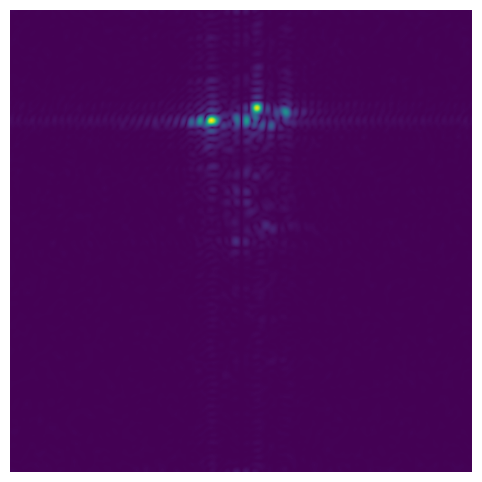

In [8]:
#magn = data_loader.get_magnitude(f"NewExp{exp_n}", 796)

# Load the magnitude from a png file
input_path = "/Users/hippolytehilgers/Downloads/RadarMagnitudes/map_533_5.png"
magn = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)

# Delete last dimension
#magn = magn[:, :, 0]

# Show the magn as image (use viriidis colormap)
plt.figure(figsize=(10, 6))
plt.imshow(magn, cmap='viridis')
#plt.colorbar()
##plt.title('Magnitude Image')
plt.axis('off')
plt.show()

In [3]:
all_train_losses = []
all_val_losses = []

exp = "Regression/BackToResNet4"
resultsPath = os.path.join("results", exp)
folds = [1,2,3,4,5,6,7,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

# Crop fold 5
all_train_losses[4] = all_train_losses[4][:10]
all_val_losses[4] = all_val_losses[4][:10]

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath)


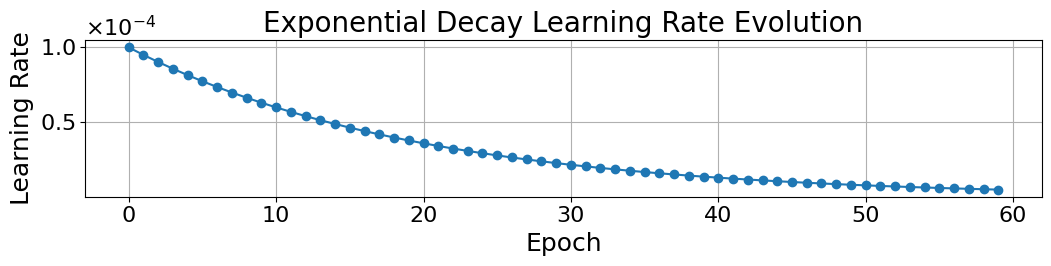

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Paramètres donnés
initial_lr = 0.0001
gamma = 0.95
epochs = 60

# Calcul du LR pour chaque epoch
lr_values = [initial_lr * (gamma ** epoch) for epoch in range(epochs)]

# 🔧 Définir les tailles de police globalement
plt.rcParams.update({
    'font.size': 18,           # taille par défaut
    'axes.titlesize': 20,      # taille du titre
    'axes.labelsize': 18,      # taille des labels x/y
    'xtick.labelsize': 16,     # taille des ticks x
    'ytick.labelsize': 16,     # taille des ticks y
    'legend.fontsize': 16,     # si tu ajoutes une légende
})

# Tracé
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Exponential Decay Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.savefig("lr_schedule_exp.pdf")


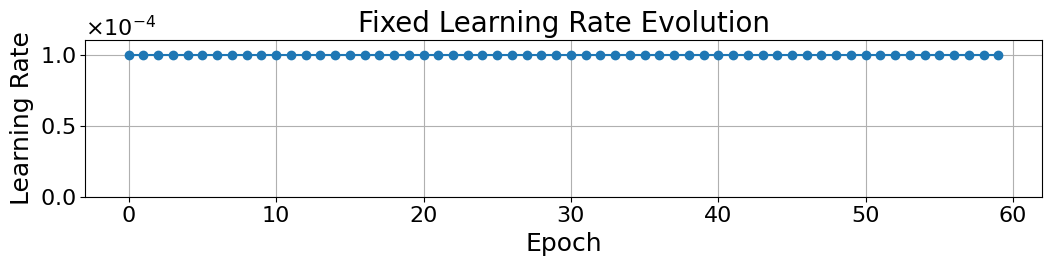

In [14]:
# 🔧 Définir les tailles de police globalement
plt.rcParams.update({
    'font.size': 18,           # taille par défaut
    'axes.titlesize': 20,      # taille du titre
    'axes.labelsize': 18,      # taille des labels x/y
    'xtick.labelsize': 16,     # taille des ticks x
    'ytick.labelsize': 16,     # taille des ticks y
    'legend.fontsize': 16,     # si tu ajoutes une légende
})

# Plot the fixed learning rate evolution
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), [initial_lr] * epochs, marker='o')
plt.title("Fixed Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)

# Garde les mêmes bornes que le tracé précédent
#plt.xlim(0, epochs - 1)
plt.ylim(0, initial_lr * 1.1)  # Ajuste la limite supérieure pour mieux voir le point

# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.savefig("lr_schedule_fixed.pdf")

/opt/homebrew/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


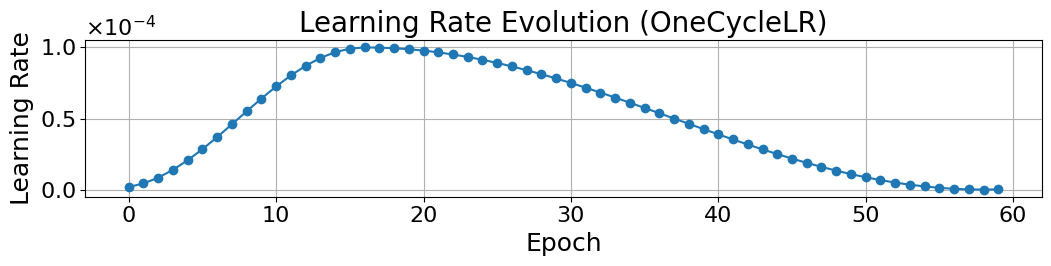

In [16]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn as nn

# Paramètres
epochs = 60
lr_start = 1e-6
max_lr = 1e-4
steps_per_epoch = 1  # pour visualisation simple : 1 update par epoch
total_steps = steps_per_epoch * epochs

# Dummy model
model = nn.Linear(10, 1)
optimizer = Adam(model.parameters(), lr=lr_start)

# Scheduler OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    anneal_strategy="cos",
    div_factor=max_lr / lr_start  # pour respecter le lr de départ donné
)

# Simuler les updates
lr_values = []
for step in range(total_steps):
    scheduler.step()
    lr_values.append(optimizer.param_groups[0]['lr'])

# 🔧 Définir les tailles de police globalement
plt.rcParams.update({
    'font.size': 18,           # taille par défaut
    'axes.titlesize': 20,      # taille du titre
    'axes.labelsize': 18,      # taille des labels x/y
    'xtick.labelsize': 16,     # taille des ticks x
    'ytick.labelsize': 16,     # taille des ticks y
    'legend.fontsize': 16,     # si tu ajoutes une légende
})

# Tracer
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution (OneCycleLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.savefig("lr_schedule_onecycle.pdf")


In [4]:
exp = "Regression/ResNet_Folds_Simple"
base_path = os.path.join("results", exp)

title = "Mean Learning Curve for fixed LR=$1 x 10^{-5}$"
#title = "Mean Learning Curve for OneCycleLR"
#title = "Mean Learning Curve for Exponential LR decay"

all_train_losses = []
all_val_losses = []

# Charger les courbes de chaque fold (1 à 8)
for fold in [2,3,5,8]:
    fold_path = os.path.join(base_path, f"fold{fold}")
    train_path = os.path.join(fold_path, "train_losses.npy")
    val_path = os.path.join(fold_path, "val_losses.npy")

    train_losses = np.load(train_path)[:60]
    val_losses = np.load(val_path)[:60]

    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

# Tracer les courbes pour tous les folds
plot_multiple_learning_curves(
    all_train_losses,
    all_val_losses,
    results_path=base_path,
    max_y=0.3,
    title=title
)

In [ ]:
exp1 = "Regression/ResNet_Folds_debug18/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

labels = ("Simple CNN - 1 path", "Simple CNN - 2 path", "Simple CNN - 2 path + ATROU")

# Stack train and val losses
train_all = [train1, train2, train3]
val_all = [val1, val2, val3]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [9]:
exp1 = "Regression/ResNet_Folds_debug25/fold5" # Nothing
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug24/fold5" # Only data augm
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug26/fold5" # Only prev frames
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Folds_debug18/fold5" # Prev frames + data augm
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("/", "DA", "PV", "PV + DA")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [ ]:
exp1 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("2nd canal", "2nd canal + Atrou")
 
# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")

In [8]:
exp1 = "Regression/ResNet_Folds_debug26/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug28/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("-1", "-2")

# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")

In [7]:
exp1 = "Regression/ResNet_Homemade_1/fold2" # D=2
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Homemade_2/fold2" # D=3
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Homemade_3/fold2" # D=4
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Homemade_4/fold2" # D=5
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("D=2", "D=3", "D=4", "D=5")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath4, max_y=0.5, title="Comparison of Learning Curves")

In [9]:
f = 2
exp1 = f"Regression/ResNet_Homemade_8/fold{f}" # N = 5
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = f"Regression/ResNet_Homemade_4/fold{f}" # N = 10
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = f"Regression/ResNet_Homemade_5/fold{f}" # N = 16
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = f"Regression/ResNet_Homemade_6/fold{f}" # N = 32
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

exp5 = f"Regression/ResNet_Homemade_7/fold{f}" # N = 64
resultsPath5 = os.path.join("results", exp5)
train5 = np.load(os.path.join(resultsPath5, "train_losses.npy"))
val5 = np.load(os.path.join(resultsPath5, "val_losses.npy"))

labels = ("N=5", "N=10", "N=16", "N=32", "N=64")

# Stack train and val losses
train_all = [train1, train2, train3, train4, train5]
val_all = [val1, val2, val3, val4, val5]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath5, max_y=0.5, title="Comparison of Learning Curves")

In [6]:
exp1 = "Regression/ResNet_Homemade_9/fold5" # D=2
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Homemade_10/fold5" # D=3
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Homemade_11/fold5" # D=4
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Homemade_12/fold5" # D=5
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("D=2", "D=3", "D=4", "D=5")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath4, max_y=0.75, title="Comparison of Learning Curves (Data augm)")

In [3]:
all_train_losses = []
all_val_losses = []

exp = "Regression/ResNet_Folds_Simple"
resultsPath = os.path.join("results", exp)
folds = [1,2,3,4,5,6,7,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    # Crop to 20 first epochs
    train_losses = train_losses[:20]
    val_losses = val_losses[:20]
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

# Set y-max
ymax = 0.5

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath, ymax)


In [5]:
# TO RUN BEFORE MEETING
f = 5
exp1 = f"Regression/ResNet_Homemade_13/fold{f}" # N = 5
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = f"Regression/ResNet_Homemade_12/fold{f}" # N = 10
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = f"Regression/ResNet_Homemade_14/fold{f}" # N = 16
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = f"Regression/ResNet_Homemade_15/fold{f}" # N = 32
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

exp5 = f"Regression/ResNet_Homemade_16/fold{f}" # N = 64
resultsPath5 = os.path.join("results", exp5)
train5 = np.load(os.path.join(resultsPath5, "train_losses.npy"))
val5 = np.load(os.path.join(resultsPath5, "val_losses.npy"))

labels = ("N=5", "N=10", "N=16", "N=32", "N=64")

# Stack train and val losses
train_all = [train1, train2, train3, train4, train5]
val_all = [val1, val2, val3, val4, val5]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath5, max_y=0.5, title="Comparison of Learning Curves")